<a href="https://colab.research.google.com/github/niko-vision/global-sales-analysis/blob/main/global_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Sales Analysis for an International Company

## Project Overview

This project focuses on cleaning, preparing, and analyzing sales data for a company that operates in the global market through both online and offline channels.

The dataset includes three tables:

- **events.csv** — transaction-level sales data collected over several years
- **products.csv** — product categories and product identifiers
- **countries.csv** — country names, regions, and country identifiers

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/MateHomework/dataset.zip

Archive:  /content/drive/MyDrive/MateHomework/dataset.zip
  inflating: 13. Final project/countries.csv  
  inflating: 13. Final project/products.csv  
  inflating: 13. Final project/events.csv  


## 1. Data Loading and Initial Exploration


At this stage, the datasets are loaded and their structure is examined, including the number of rows and columns, data types, and missing values.

For each table, the following aspects were reviewed:

- dataset shape
- data types
- missing values

> *The checks are grouped together for clearer presentation and easier comparison across tables*

In [ ]:
countries_df = pd.read_csv("/content/13. Final project/countries.csv")
products_df = pd.read_csv("/content/13. Final project/products.csv")
events_df = pd.read_csv("/content/13. Final project/events.csv")

In [ ]:
countries_df.shape
countries_df.info()
countries_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


,0
name,0
alpha-2,1
alpha-3,0
region,1
sub-region,1


In [ ]:
products_df.shape
products_df.info()
products_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


,0
id,0
item_type,0


In [ ]:
events_df.shape
events_df.info()
events_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,82
Product ID,0
Sales Channel,0
Units Sold,2
Unit Price,0
Unit Cost,0


## 2. Data Cleaning and Preparation

At this stage, the data is cleaned and prepared for further analysis. This includes standardizing column names, removing extra spaces in text fields, checking missing values, reviewing data types, identifying duplicates, and examining potential anomalies.

These steps are necessary to reduce the risk of errors during table merging and further analysis.

 ### • 2.1 Standardizing Column Names


In [ ]:
def clean_columns(df):
  df.columns= (df.columns
               .str.strip()
               .str.lower()
               .str.replace(" ","_")
               .str.replace("-","_")
               )
  return df

In [ ]:
#Apply the function to each table
countries_df = clean_columns(countries_df)
products_df = clean_columns(products_df)
events_df = clean_columns(events_df)
events_df.info() #Check the result

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        1330 non-null   int64  
 1   order_date      1330 non-null   object 
 2   ship_date       1330 non-null   object 
 3   order_priority  1330 non-null   object 
 4   country_code    1248 non-null   object 
 5   product_id      1330 non-null   int64  
 6   sales_channel   1330 non-null   object 
 7   units_sold      1328 non-null   float64
 8   unit_price      1330 non-null   float64
 9   unit_cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


### • 2.2 Cleaning Text Fields (Trimming)

Text columns (`object` type) were identified in each table for further cleaning.

Leading and trailing spaces were removed from text fields to prevent inconsistencies, duplicate-like values, and merge issues in later steps.

In [ ]:
events_df.select_dtypes(include="object").columns
countries_df.select_dtypes(include="object").columns
products_df.select_dtypes(include="object").columns

Index(['item_type'], dtype='object')

In [ ]:
for col in events_df.select_dtypes(include="object").columns:
    events_df[col] = events_df[col].str.strip()

for col in countries_df.select_dtypes(include="object").columns:
    countries_df[col] = countries_df[col].str.strip()

for col in products_df.select_dtypes(include="object").columns:
    products_df[col] = products_df[col].str.strip()

### • 2.3 Checking Missing Values (%)

The share of missing values was calculated for each column to assess data quality and support further cleaning decisions.

In [ ]:
print(countries_df.isna().sum() / countries_df.shape[0] * 100)

name          0.000000
alpha_2       0.401606
alpha_3       0.000000
region        0.401606
sub_region    0.401606
dtype: float64


In [ ]:
print(events_df.isna().sum() / events_df.shape[0] * 100)

order_id          0.000000
order_date        0.000000
ship_date         0.000000
order_priority    0.000000
country_code      6.165414
product_id        0.000000
sales_channel     0.000000
units_sold        0.150376
unit_price        0.000000
unit_cost         0.000000
dtype: float64


In the `countries` table, the share of missing values is very low (around 0.4%) and is not critical for further analysis.

In the `events` table, the highest share of missing values is observed in the `country_code` column (around 6%), which may affect the accuracy of merging with the country reference table. Other columns contain either no missing values or only a negligible share.

---

Overall, the data quality is acceptable, but `country_code` requires additional attention before performing the JOIN.

### •  2.4 Handling a Specific Data Correction

A missing `alpha_2` code in the `countries` table was filled for Namibia
(`NAM` -> `NA`).

After this correction, the remaining missing values were related to Antarctica, which does not belong to a standard region or sub-region in this dataset.

In [ ]:
countries_df.loc[countries_df["alpha_3"] == "NAM", "alpha_2"] = "NA"
countries_df[countries_df.isna().any(axis=1)]

,name,alpha_2,alpha_3,region,sub_region
8,Antarctica,AQ,ATA,NaN,NaN


### • 2.5  Detailed Review of Missing Values in `events_df`


Records with missing `country_code` values were reviewed in more detail to understand whether the missing data was limited to one field or accompanied by other patterns.

> *The checks were grouped together for easier review*

In [ ]:
missing_country = events_df[events_df["country_code"].isna()]
missing_country.shape
missing_country.head()
missing_country["sales_channel"].value_counts()
missing_country["product_id"].value_counts().head(10)

,count
product_id,
8681,10
4594,9
5988,9
8969,8
1270,8
8875,8
7331,7
7940,6
3127,6


#### Decision on `country_code`

82 missing values were found (6.16%)

At this stage, they were left unchanged because they may be:

- recovered after merging with the countries table
- handled after reviewing the data structure

### • 2.6 Missing Values in `units_sold`


2 missing values were found (0.15%)

Since this is a key financial metric, the records were removed to avoid distorting the calculations.

In [ ]:
events_df = events_df.dropna(subset=["units_sold"])
events_df["units_sold"].isna().sum()

np.int64(0)

### • 2.7 Checking for Full Duplicates


**No full duplicates were found in any of the tables.**


In [ ]:
events_df.duplicated().sum()
countries_df.duplicated().sum()
products_df.duplicated().sum()

np.int64(0)

 ### • 2.8 Checking Logical Anomalies

No negative values were found in `units_sold`.

No cases were found where `unit_cost` exceeded `unit_price`.

In [ ]:
events_df[events_df["units_sold"] < 0]

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost


In [ ]:
events_df[events_df["unit_cost"] > events_df["unit_price"]]

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost


###  • 2.9 Normalizing Categorical Values

Unique values in `order_priority` were reviewed.

In the `sales_channel` column, duplicate values caused by letter case were found, so the values were normalized to lowercase.

In [ ]:
events_df["order_priority"].unique()
events_df["sales_channel"] = events_df["sales_channel"].str.lower()
events_df["sales_channel"].unique()

array(['online', 'offline'], dtype=object)

## 3. Merging the Tables

In [ ]:
import sqlite3

conn = sqlite3.connect(":memory:")

events_df.to_sql("events", conn, index=False, if_exists="replace")
products_df.to_sql("products", conn, index=False, if_exists="replace")
countries_df.to_sql("countries", conn, index=False, if_exists="replace")

249

The three tables were merged using `LEFT JOIN` to create a single dataset for further analysis.

- `events` - main sales fact table
- `products` - joined by `product_id`
- `countries` - joined by country code (`alpha_3`)

As a result, a unified dataframe was created for the next stages of analysis.

In [ ]:
query = """
SELECT
    e.order_id,
    e.order_date,
    e.ship_date,
    e.order_priority,
    e.country_code,
    c.name AS country_name,
    c.region,
    c.sub_region,
    e.product_id,
    p.item_type,
    e.sales_channel,
    e.units_sold,
    e.unit_price,
    e.unit_cost
FROM events e
LEFT JOIN products p
    ON e.product_id = p.id
LEFT JOIN countries c
    ON e.country_code = c.alpha_3
"""

merged_df = pd.read_sql(query, conn)
merged_df.head(10)

,order_id,order_date,ship_date,order_priority,country_code,country_name,region,sub_region,product_id,item_type,sales_channel,units_sold,unit_price,unit_cost
0,100640618,10/8/2014,10/18/2014,M,NOR,Norway,Europe,Northern Europe,2103,Cereal,online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,Serbia,Europe,Southern Europe,2103,Cereal,offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,None,None,None,None,7940,Household,online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,Montenegro,Europe,Southern Europe,2455,Clothes,online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,Serbia,Europe,Southern Europe,1270,Beverages,offline,7648.0,47.45,31.79
5,103450715,3/15/2015,4/18/2015,H,SVK,Slovakia,Europe,Eastern Europe,8681,Office Supplies,online,2220.0,651.21,524.96
6,103499639,4/20/2013,6/6/2013,L,FRA,France,Europe,Western Europe,4594,Fruits,online,6698.0,9.33,6.92
7,103762280,11/12/2011,12/14/2011,M,ESP,Spain,Europe,Southern Europe,5988,Vegetables,online,4419.0,154.06,90.93
8,103832662,9/19/2012,10/20/2012,H,HRV,Croatia,Europe,Southern Europe,7331,Baby Food,offline,5247.0,255.28,159.42
9,104008615,1/23/2011,2/22/2011,M,DEU,Germany,Europe,Western Europe,2103,Cereal,online,7315.0,205.70,117.11


In [ ]:
merged_df.shape

(1328, 14)

In [ ]:
events_df.shape

(1328, 10)

After merging, technical identifiers (`product_id`, `country_code`) were removed, since descriptive fields are used for further analysis.


In [ ]:
merged_df = merged_df.drop(columns=["product_id", "country_code"])
merged_df.head(5)

,order_id,order_date,ship_date,order_priority,country_name,region,sub_region,item_type,sales_channel,units_sold,unit_price,unit_cost
0,100640618,10/8/2014,10/18/2014,M,Norway,Europe,Northern Europe,Cereal,online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,Serbia,Europe,Southern Europe,Cereal,offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,None,None,None,Household,online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,Montenegro,Europe,Southern Europe,Clothes,online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,Serbia,Europe,Southern Europe,Beverages,offline,7648.0,47.45,31.79


The `order_date` and `ship_date` columns were converted to datetime format to ensure correct time-based analysis.

In [ ]:
merged_df["order_date"] = pd.to_datetime(merged_df["order_date"])
merged_df["ship_date"] = pd.to_datetime(merged_df["ship_date"])
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1328 non-null   int64         
 1   order_date      1328 non-null   datetime64[ns]
 2   ship_date       1328 non-null   datetime64[ns]
 3   order_priority  1328 non-null   object        
 4   country_name    1246 non-null   object        
 5   region          1246 non-null   object        
 6   sub_region      1246 non-null   object        
 7   item_type       1328 non-null   object        
 8   sales_channel   1328 non-null   object        
 9   units_sold      1328 non-null   float64       
 10  unit_price      1328 non-null   float64       
 11  unit_cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(1), object(6)
memory usage: 124.6+ KB


### Handling Missing Values After the Join

In [ ]:

merged_df[['country_name','region','sub_region']].isna().sum()

merged_df['country_name'] = merged_df['country_name'].fillna('Unknown')
merged_df[merged_df['country_name'] == 'Unknown'].shape

(82, 12)

## 4. Key Business Metrics

The main business metrics were calculated to give an overall view of sales performance.

In [ ]:
#Total number of orders
total_orders = merged_df["order_id"].nunique()
print(f"Total orders :{total_orders}")

Total orders :1328


In [ ]:
#Total units sold
total_units = int(merged_df['units_sold'].sum())
print(f"Total units sold: {total_units}")

Total units sold: 6576524


In [ ]:
#Total revenue
merged_df['revenue'] = merged_df['units_sold'] * merged_df['unit_price']
total_revenue = merged_df['revenue'].sum()
print(f"Total revenue: ${total_revenue:,.2f}")

Total revenue: $1,702,129,408.21


In [ ]:
#Total profit
merged_df['profit'] = merged_df['units_sold'] * (merged_df['unit_price']-merged_df['unit_cost'])
total_profit = merged_df['profit'].sum()
print(f"Total profit: ${total_profit:,.2f}")

Total profit: $501,434,459.00


## 5. Visualization

###  • 5.1 Time Trend Analysis

#### • 5.1.1 Revenue and Profit by Year


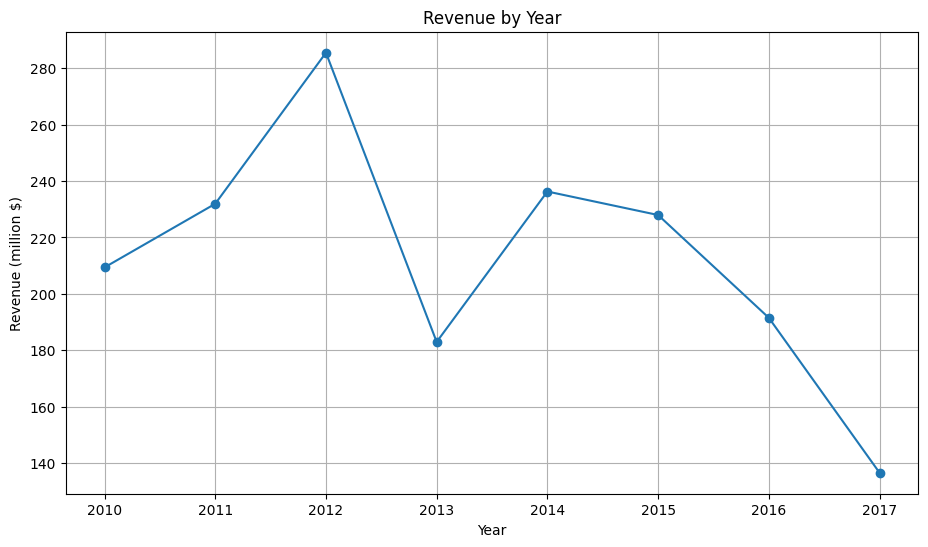

In [ ]:
revenue_by_year = merged_df.groupby(merged_df['order_date'].dt.year)['revenue'].sum()
revenue_by_year = revenue_by_year.round(2)

revenue_by_year_mln = revenue_by_year / 1_000_000

plt.figure(figsize=(11,6))
plt.plot(revenue_by_year_mln.index, revenue_by_year_mln.values, marker='o')

plt.title("Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue (million $)")

plt.grid(True)
plt.xticks(revenue_by_year_mln.index)
plt.show()

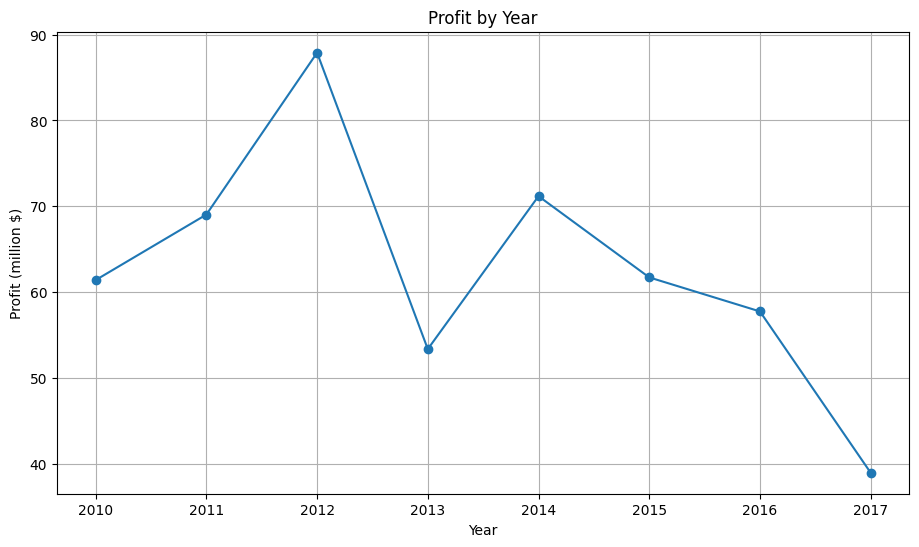

In [ ]:
profit_by_year = merged_df.groupby(merged_df['order_date'].dt.year)['profit'].sum()

profit_by_year_mln = profit_by_year / 1_000_000

plt.figure(figsize=(11,6))
plt.plot(profit_by_year_mln.index, profit_by_year_mln.values, marker='o')

plt.title("Profit by Year")
plt.xlabel("Year")
plt.ylabel("Profit (million $)")
plt.ticklabel_format(style='plain', axis='y')

plt.grid(True)
plt.xticks(profit_by_year_mln.index)
plt.show()

####  • 5.1.2 Revenue and Profit by Month


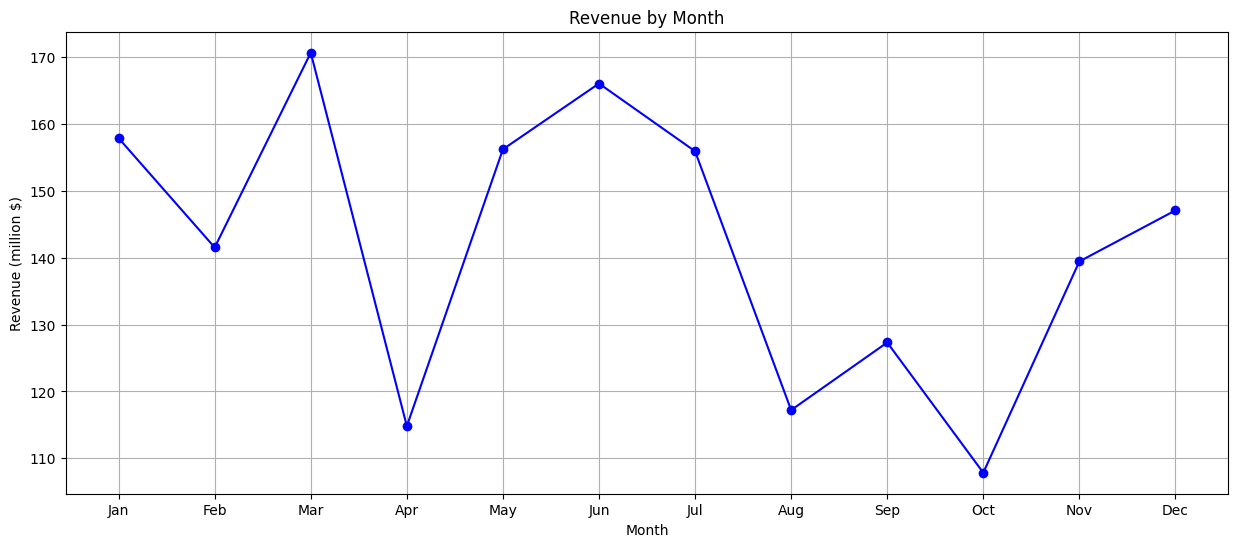

In [ ]:
revenue_by_month = merged_df.groupby(merged_df['order_date'].dt.month)['revenue'].sum()

revenue_by_month_mln = revenue_by_month/1_000_000

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


plt.figure(figsize=(15,6))
plt.plot(revenue_by_month_mln.index, revenue_by_month_mln.values, marker='o',color='b')

plt.title("Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue (million $)")
plt.xticks(revenue_by_month_mln.index,labels=months)
plt.grid(True)

plt.show()

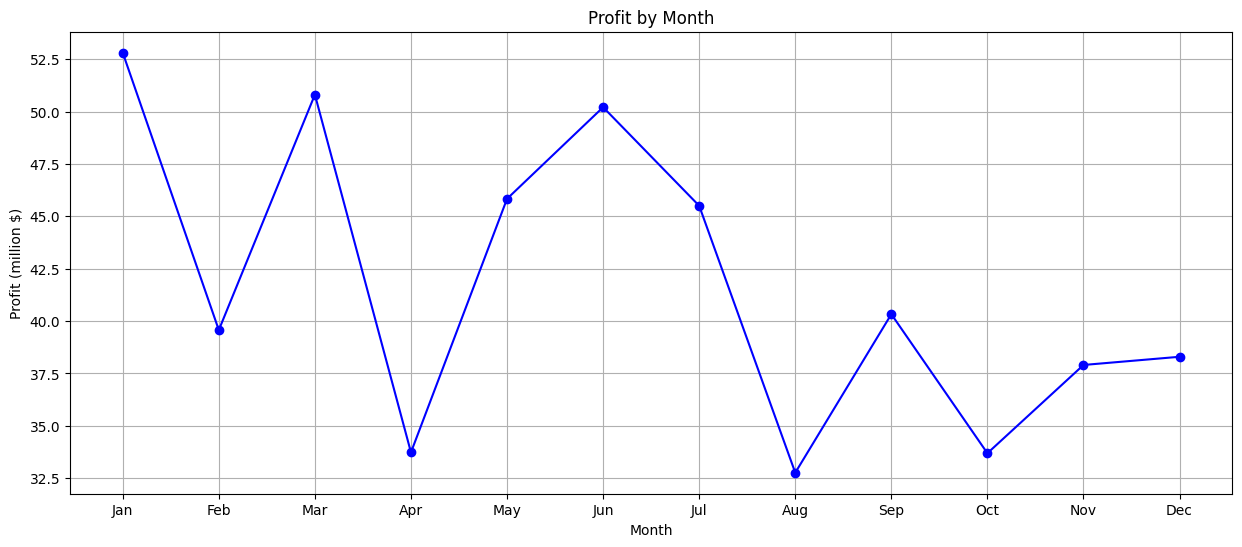

In [ ]:
profit_by_month = merged_df.groupby(merged_df['order_date'].dt.month)['profit'].sum()

profit_by_month_mln = profit_by_month/1_000_000

plt.figure(figsize=(15,6))
plt.plot(profit_by_month_mln.index, profit_by_month_mln.values, marker='o',color='b')

plt.title("Profit by Month")
plt.xlabel("Month")
plt.ylabel("Profit (million $)")
plt.xticks(profit_by_month_mln.index,labels=months)
plt.grid(True)

plt.show()

####  • 5.1.3 Revenue and Profit by Day of Week


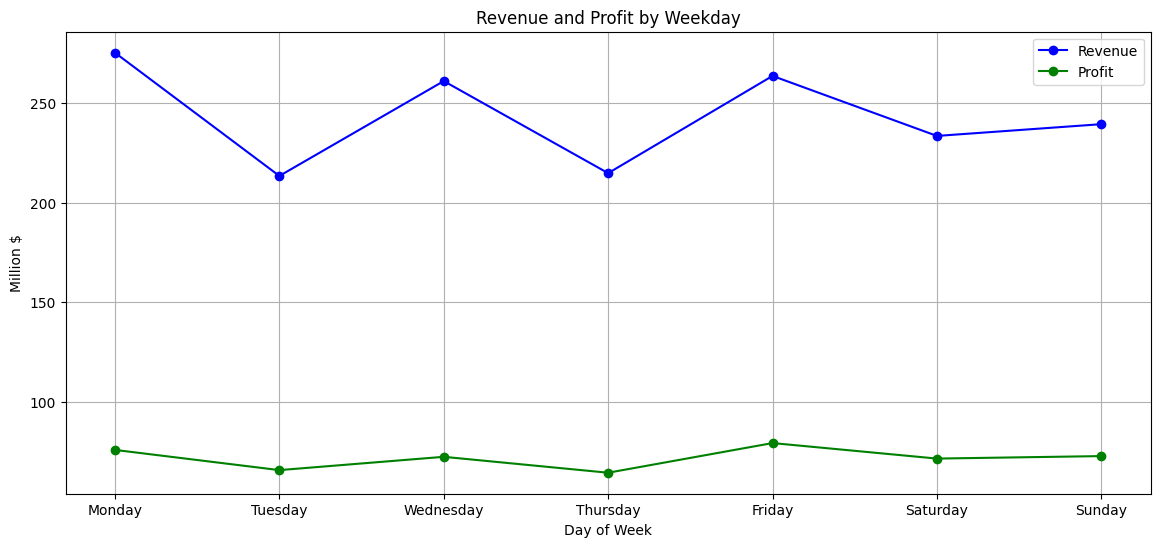

In [ ]:
merged_df['day_of_week'] = merged_df['order_date'].dt.day_name()
weekday_stats = merged_df.groupby('day_of_week')[['revenue','profit']].sum()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

weekday_stats = weekday_stats.reindex(order)

weekday_stats_mln = weekday_stats / 1_000_000

plt.figure(figsize=(14,6))

plt.plot(weekday_stats_mln.index,
         weekday_stats_mln['revenue'],
         marker='o',
         label='Revenue',
         color='b')

plt.plot(weekday_stats_mln.index,
         weekday_stats_mln['profit'],
         marker='o',
         label='Profit',
         color='g')

plt.title("Revenue and Profit by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Million $")
plt.legend()
plt.grid(True)

plt.show()

### • 5.2 Geographic Analysis


#### • 5.2.1 Top 10 Countries by Revenue and Profit

Some records have `country_name = 'Unknown'`

These records account for:

- Total Revenue: $103.1 million

- Total Profit: $27.7 million

**To make the ranking more accurate, these values were excluded from the visualization**

In [ ]:
unknown_revenue = merged_df.loc[merged_df['country_name']=='Unknown', 'revenue'].sum()
print(f"Unknown revenue: ${unknown_revenue:,.2f}")
unknown_profit = merged_df.loc[merged_df['country_name']=='Unknown', 'profit'].sum()
print(f"Unknown profit: ${unknown_profit:,.2f}")

Unknown revenue: $103,145,646.95
Unknown profit: $27,725,423.94


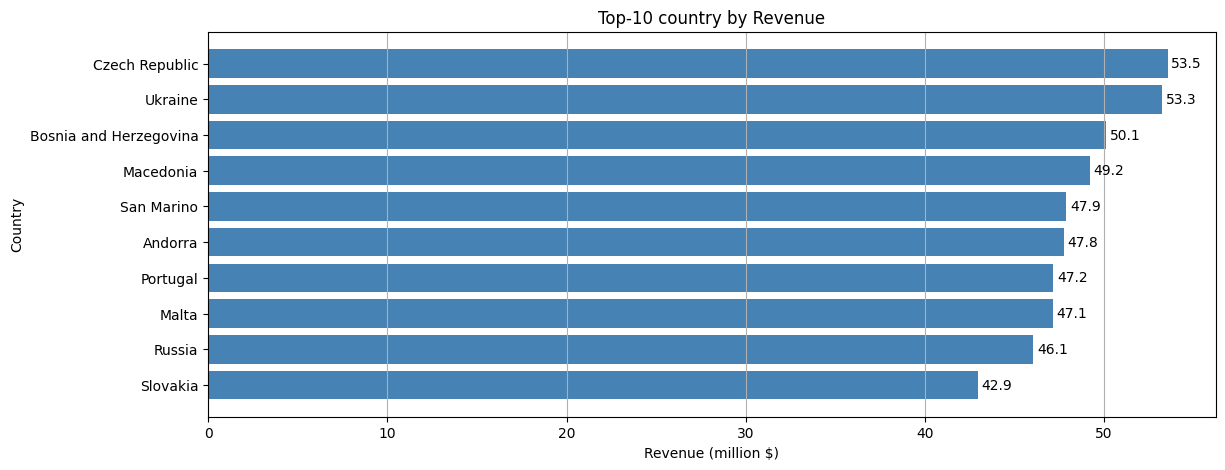

In [ ]:
top10_countries = (
    merged_df[merged_df['country_name'] != 'Unknown'].groupby('country_name')['revenue'].sum().sort_values(ascending=False).head(10)
    )
top10_mln = top10_countries/1_000_000


plt.figure(figsize=(13,5))

plt.barh(top10_mln.index, top10_mln.values, color='steelblue')

for i, v in enumerate(top10_mln.values):
    plt.text(v + 0.2, i, f"{v:.1f}", va='center')

plt.title("Top-10 country by Revenue")
plt.xlabel("Revenue (million $)")
plt.ylabel("Country")

plt.gca().invert_yaxis()
plt.grid(axis='x')

plt.show()

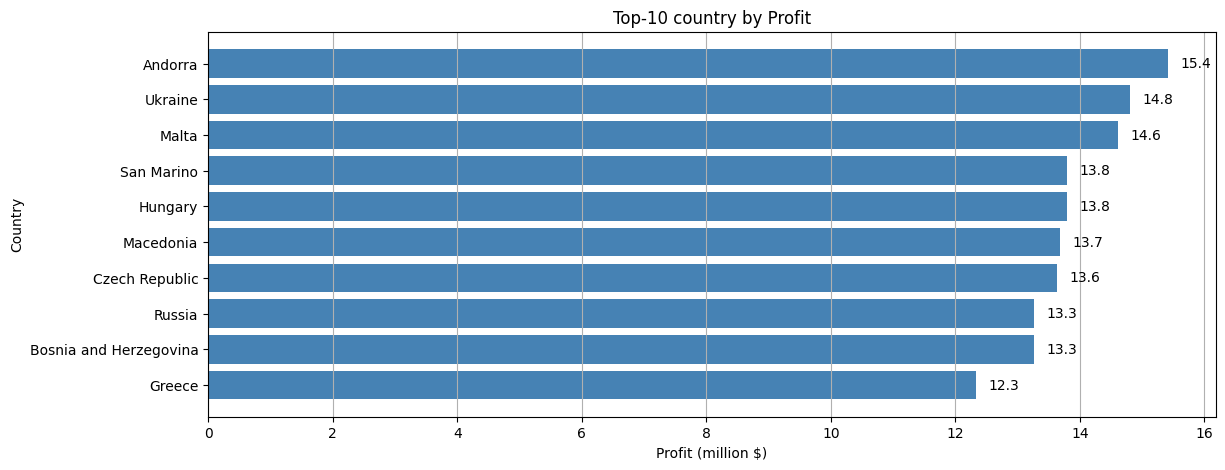

In [ ]:
top10_countries_profit = (
    merged_df[merged_df['country_name'] != 'Unknown'].groupby('country_name')['profit'].sum().sort_values(ascending=False).head(10)
    )

top10_profit_mln = top10_countries_profit/1_000_000

plt.figure(figsize=(13,5))

plt.barh(top10_profit_mln.index, top10_profit_mln.values, color='steelblue')

for i, v in enumerate(top10_profit_mln.values):
    plt.text(v + 0.2, i, f"{v:.1f}", va='center')

plt.title("Top-10 country by Profit")
plt.xlabel("Profit (million $)")
plt.ylabel("Country")

plt.gca().invert_yaxis()
plt.grid(axis='x')

plt.show()

#### • 5.2.2 Geographic Concentration Assessment

To assess the level of geographic concentration, the share of total revenue and profit generated by the top 5 countries was calculated.

- share of revenue from the top 5 countries: 14.9%
- share of profit from the top 5 countries: 14.4%

These values indicate that there is no strong geographic concentration.

**Revenue and profit are distributed relatively evenly across countries.**

In [ ]:
revenue_by_country = (
    merged_df[merged_df['country_name'] != 'Unknown'].groupby('country_name')['revenue'].sum().sort_values(ascending=False)
    )

profit_by_country = (
    merged_df[merged_df['country_name'] != 'Unknown'].groupby('country_name')['profit'].sum().sort_values(ascending=False)
)

In [ ]:
top5_revenue = revenue_by_country.head(5).sum()
concentration_revenue = top5_revenue / total_revenue * 100

top5_profit = profit_by_country.head(5).sum()
concentration_profit = top5_profit / total_profit * 100

print(f"Частка доходу топ-5 країн: {concentration_revenue:.1f}%")
print(f"Частка прибутку топ-5 країн: {concentration_profit:.1f}%")

Частка доходу топ-5 країн: 14.9%
Частка прибутку топ-5 країн: 14.4%


#### • 5.2.3 Revenue and Profit by Region

Values labeled as `Unknown` for the region represent aggregated data for countries without a defined region and do not add analytical value.

---

The distribution of revenue and profit across regions is highly concentrated: about 95% comes from Europe, while Asia accounts for only about 5%.

---

**This indicates a strong dependence on the European market.**

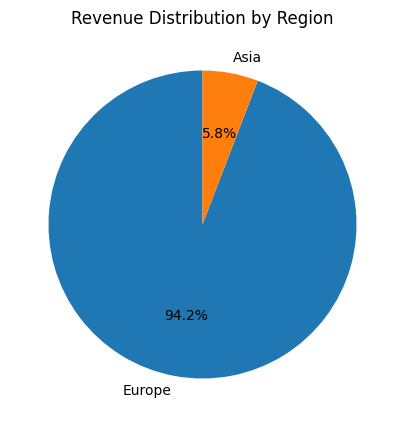

In [ ]:
revenue_by_region = merged_df[merged_df['region'] != 'Unknown'].groupby('region')['revenue'].sum().sort_values(ascending=False).head()

revenue_share_region = revenue_by_region / revenue_by_region.sum() * 100

plt.figure(figsize=(5,5))

plt.pie(
    revenue_share_region.values,
    labels=revenue_share_region.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Revenue Distribution by Region")
plt.show()

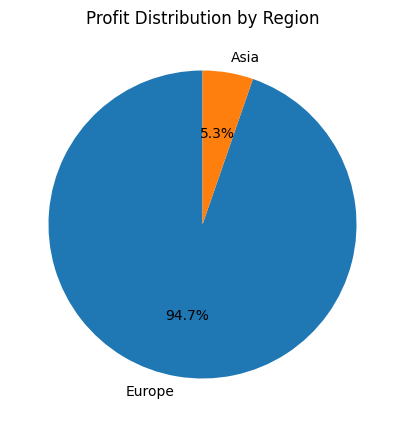

In [ ]:
profit_by_region = merged_df[merged_df['region'] != 'Unknown'].groupby('region')['profit'].sum().sort_values(ascending=False).head()

profit_share_region = profit_by_region / profit_by_region.sum() * 100

plt.figure(figsize=(5,5))

plt.pie(
    profit_share_region.values,
    labels=profit_share_region.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Profit Distribution by Region")
plt.show()

### • 5.3 Product Category Analysis

#### • 5.3.1	Products by Units Sold

The highest sales volume is observed in **Office Supplies** and **Beverages**.

**Office Supplies** leads in revenue, while **Cosmetics** generates the highest profit.

The lowest revenue and profit are observed in the **Fruits** category.

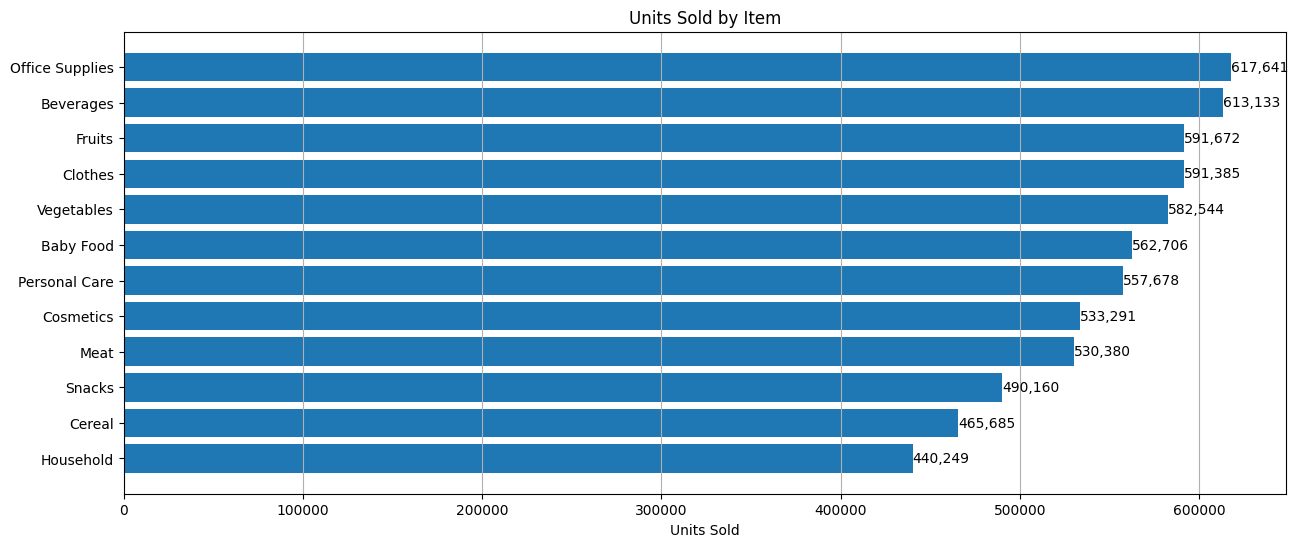

In [ ]:
units_by_item = merged_df.groupby('item_type')['units_sold'].sum().sort_values(ascending=False)

plt.figure(figsize=(15,6))
plt.barh(units_by_item.index, units_by_item.values)
plt.title("Units Sold by Item")
plt.xlabel("Units Sold")
plt.gca().invert_yaxis()

for i, v in enumerate(units_by_item.values):
    plt.text(v, i, f"{int(v):,}", va='center')

plt.grid(axis='x')
plt.show()

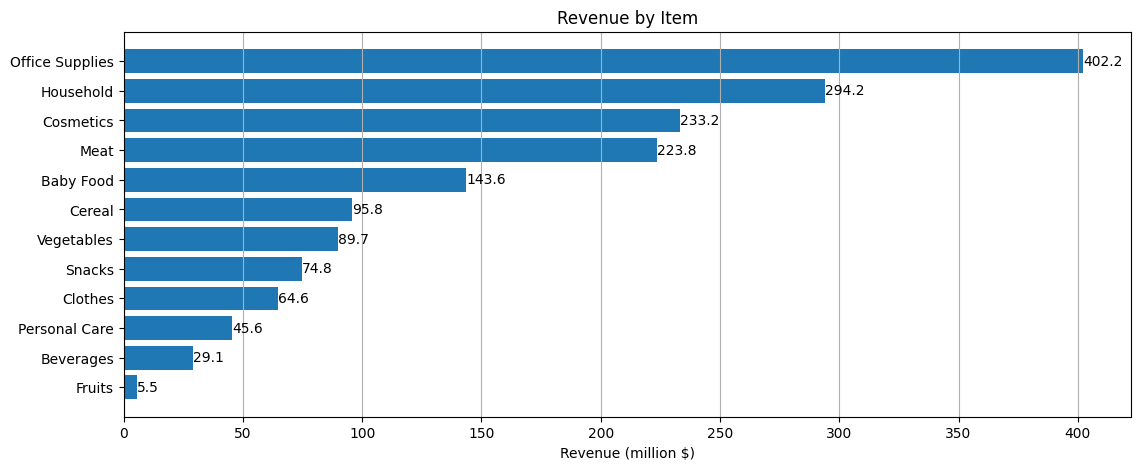

In [ ]:
revenue_by_item = merged_df.groupby('item_type')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(13,5))
plt.barh(revenue_by_item.index, revenue_by_item.values / 1_000_000)
plt.title("Revenue by Item")
plt.xlabel("Revenue (million $)")
plt.gca().invert_yaxis()

for i, v in enumerate(revenue_by_item.values / 1_000_000):
    plt.text(v, i, f"{v:.1f}", va='center')

plt.grid(axis='x')
plt.show()

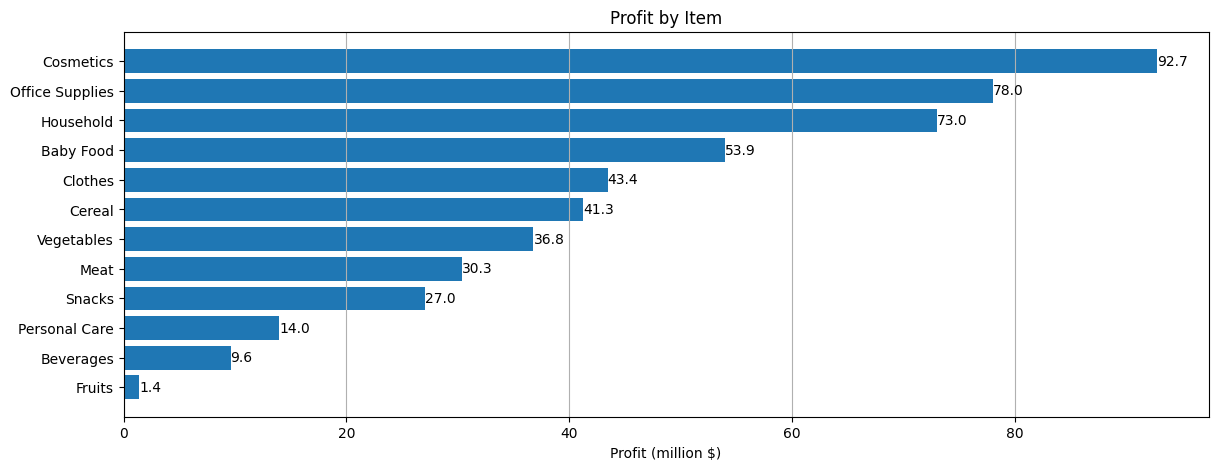

In [ ]:
profit_by_item = merged_df.groupby('item_type')['profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(14,5))
plt.barh(profit_by_item.index, profit_by_item.values / 1_000_000)
plt.title("Profit by Item")
plt.xlabel("Profit (million $)")
plt.gca().invert_yaxis()

for i, v in enumerate(profit_by_item.values / 1_000_000):
    plt.text(v, i, f"{v:.1f}", va='center')

plt.grid(axis='x')
plt.show()

#### • 5.3.2	Product Margins

The highest margin is observed in the **Clothes** category (~67%).

The lowest margins are found in **Meat** (≈14%) and **Office Supplies** (≈19%)


High revenue does not always mean high profitability.

In [ ]:
item_stats = merged_df.groupby('item_type')[['revenue', 'profit']].sum()
item_stats['margin'] = item_stats['profit'] / item_stats['revenue']
item_stats = item_stats.sort_values('margin',ascending=False)

item_stats

,revenue,profit,margin
item_type,,,
Clothes,6.462655e+07,43431314.40,0.672035
Cereal,9.579140e+07,41255034.15,0.430676
Vegetables,8.974673e+07,36776002.72,0.409775
Cosmetics,2.331548e+08,92723306.17,0.397690
Baby Food,1.436476e+08,53940997.16,0.375509
Snacks,7.478861e+07,27027422.40,0.361384
Beverages,2.909316e+07,9601662.78,0.330032
Personal Care,4.557902e+07,13975410.68,0.306619
Fruits,5.520300e+06,1425929.52,0.258307


### • 5.4	Sales Channel Analysis



Online and offline sales are distributed almost equally in terms of units sold, revenue, and profit.

Offline has a slight advantage in revenue (51% vs 49%), but the difference is minimal.

Overall, the business does not depend on a single channel: both channels contribute comparably to the results.

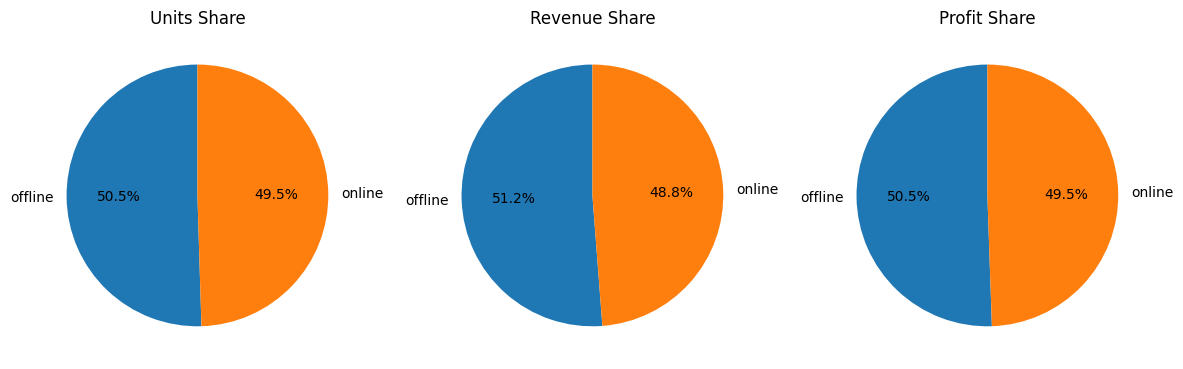

In [ ]:
channel_stats = merged_df.groupby('sales_channel')[['units_sold','revenue','profit']].sum()

fig, ax = plt.subplots(1, 3, figsize=(12,5))

# Units
ax[0].pie(channel_stats['units_sold'],
          labels=channel_stats.index,
          autopct='%1.1f%%',
          startangle=90)
ax[0].set_title("Units Share")

# Revenue
ax[1].pie(channel_stats['revenue'],
          labels=channel_stats.index,
          autopct='%1.1f%%',
          startangle=90)
ax[1].set_title("Revenue Share")

# Profit
ax[2].pie(channel_stats['profit'],
          labels=channel_stats.index,
          autopct='%1.1f%%',
          startangle=90)
ax[2].set_title("Profit Share")

plt.tight_layout()
plt.show()

### • 5.5 Impact of Delivery Time on Profit



No clear linear relationship is observed between delivery time and average profit.

Profit fluctuates across different delivery times, without a stable upward or downward trend.

In [ ]:
merged_df['ship_time_days'] = (merged_df['ship_date'] - merged_df['order_date']).dt.days

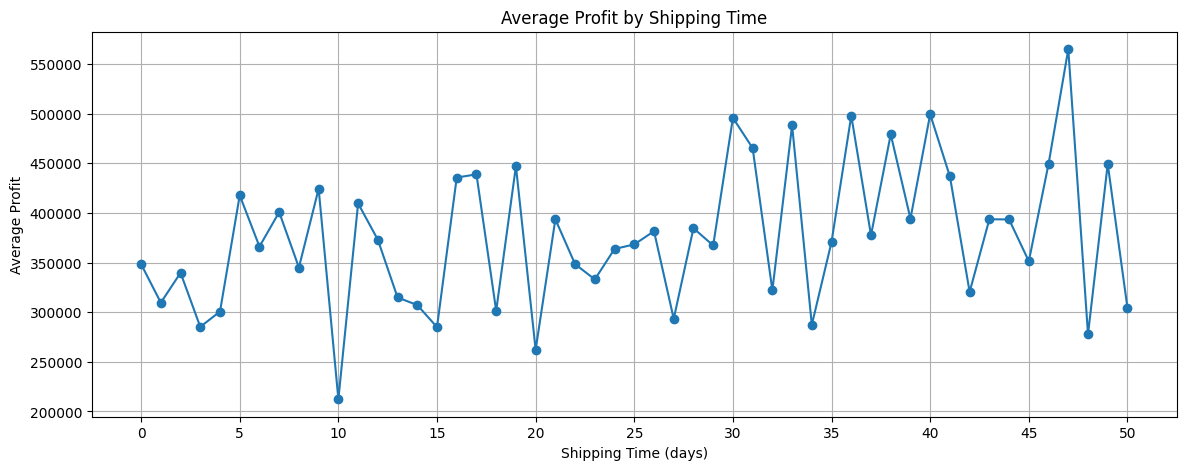

In [ ]:
ship_profit = (merged_df.groupby('ship_time_days')['profit'].mean().reset_index())

plt.figure(figsize=(14,5))
plt.plot(ship_profit['ship_time_days'],
         ship_profit['profit'],
         marker='o')

plt.xticks(range(0, int(ship_profit['ship_time_days'].max()) + 1, 5))

plt.title("Average Profit by Shipping Time")
plt.xlabel("Shipping Time (days)")
plt.ylabel("Average Profit")
plt.grid(True)


plt.show()

## 6. Conclusions

- The company’s revenue grew until 2012 (peak: about $285 million), then declined, with partial recovery in 2014–2015 and a downward trend again from 2016 onward.

- **Office Supplies, Cosmetics, and Household** consistently make the largest contribution to revenue and profit.

- Online and Offline channels generate comparable profit, so the business is not dependent on a single channel.

- **Europe** remains the company’s main market.

- No clear linear relationship was found between delivery time and average profit.